In [4]:
import numpy as np
from os import listdir

from ExistingAlgorithms.Plot import plot_traces
from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.decibels import file_name_table_npy, decibel_table_bin
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.utils.confidence import confidence
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.manifold import TSNE
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from sklearn.decomposition import PCA

In [5]:
signal_size = 30_000
path_train = 'Datasets/TES/NIST test'
path_model = 'grid-search-TES Triplet 13/run 08/fold 0'#'grid-search-TES param 4/run 14/fold 0'#run-2024-01-18-18-15/fold 0'
mean_model, std_model = load_mean_std(path_model)

# Poissonian statistic for Autoencoder

In [8]:
X, decibel_samples = decibel_table_bin('Datasets/TES/NIST test',
                                8192,
                                (67,71))

X = -1* X[:,0:270]
X = (X - mean_model) / std_model
#X = X[:,::2]

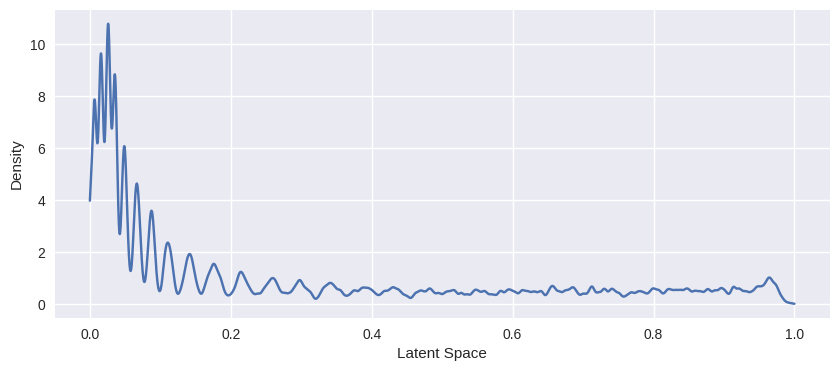

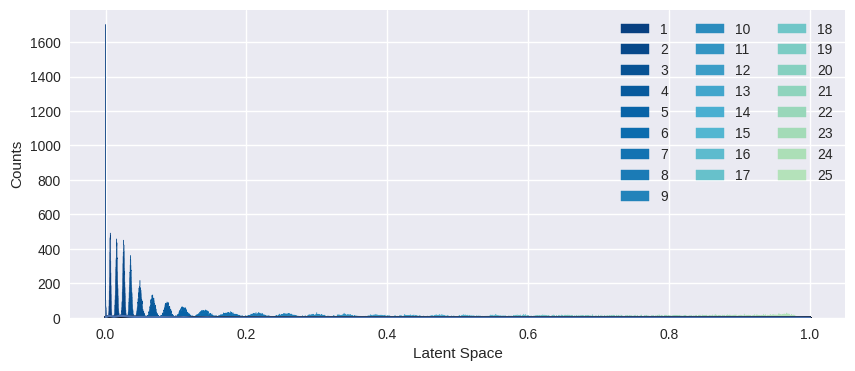

25.0


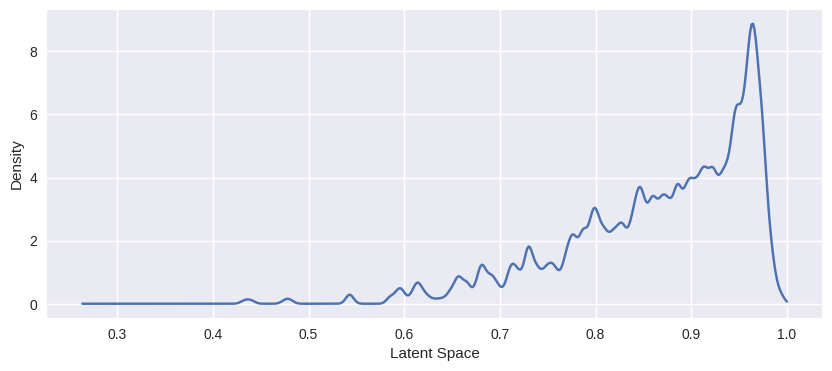

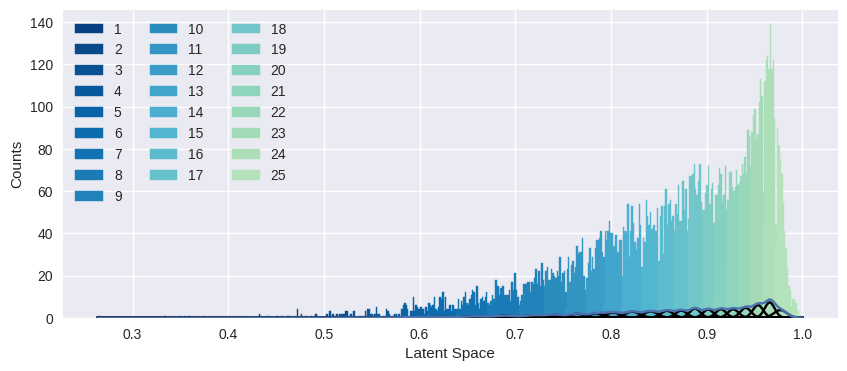

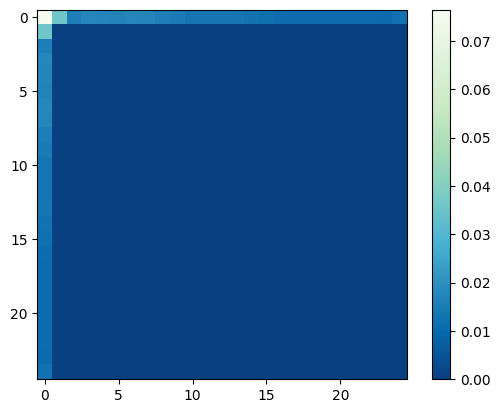

mean 22.01806640625


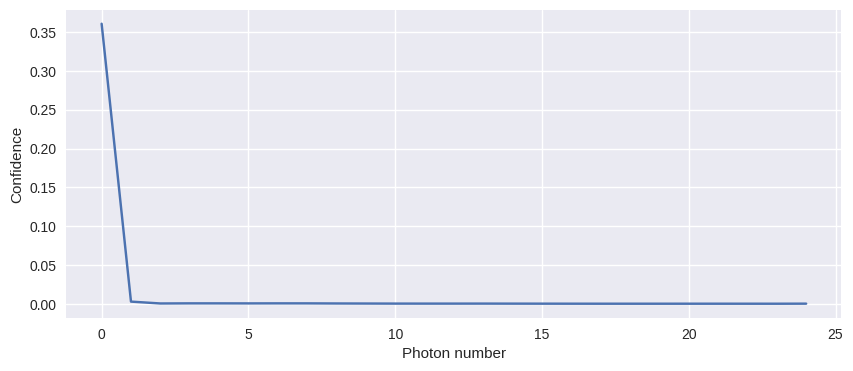

25.5


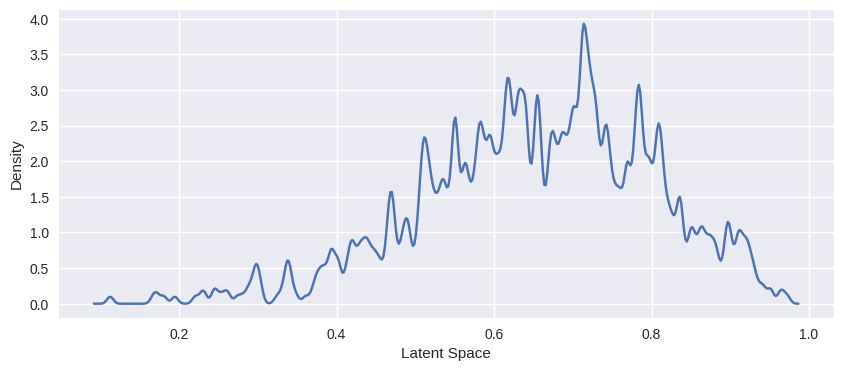

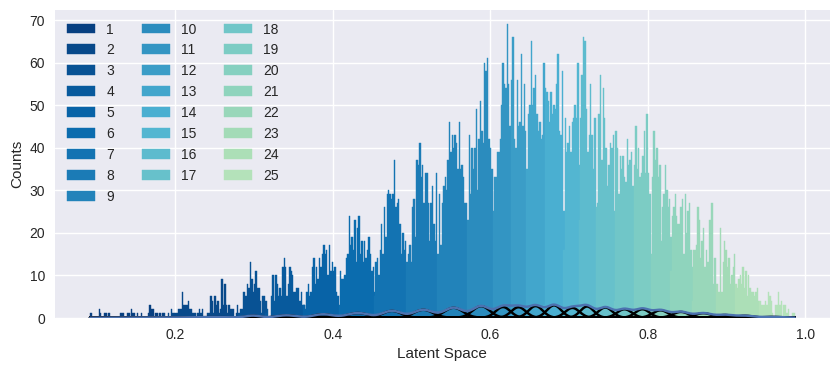

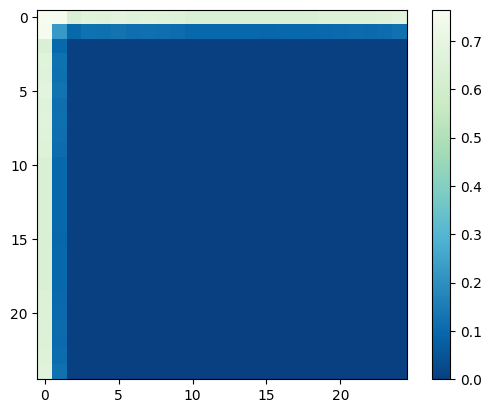

mean 17.24111328125


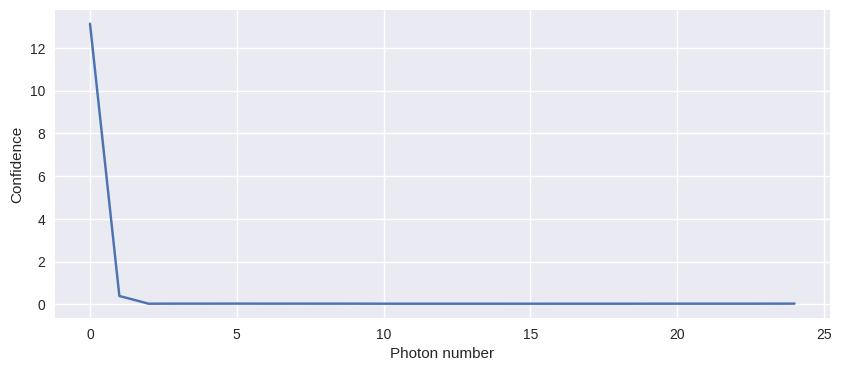

26.0


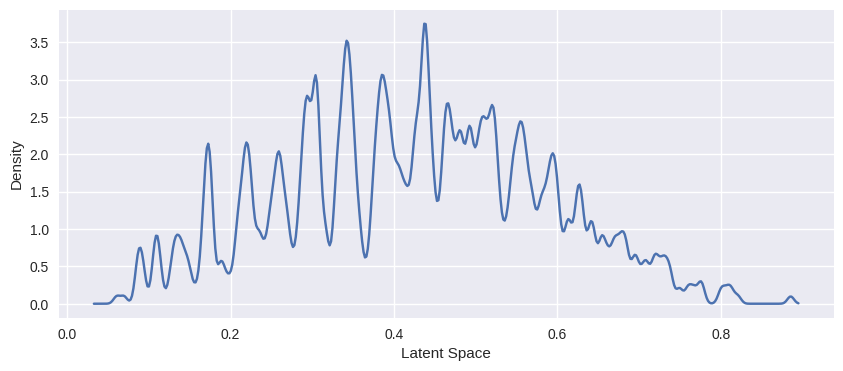

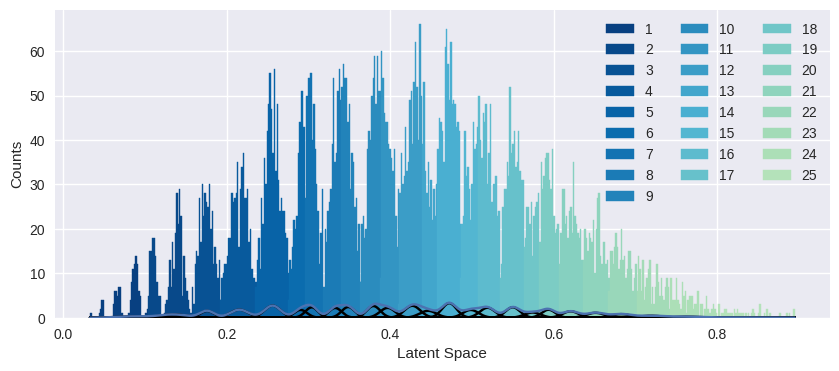

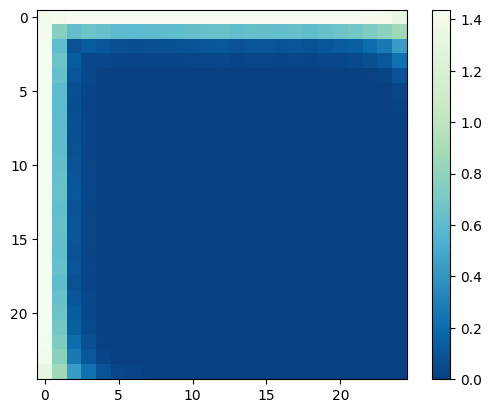

mean 11.822265625


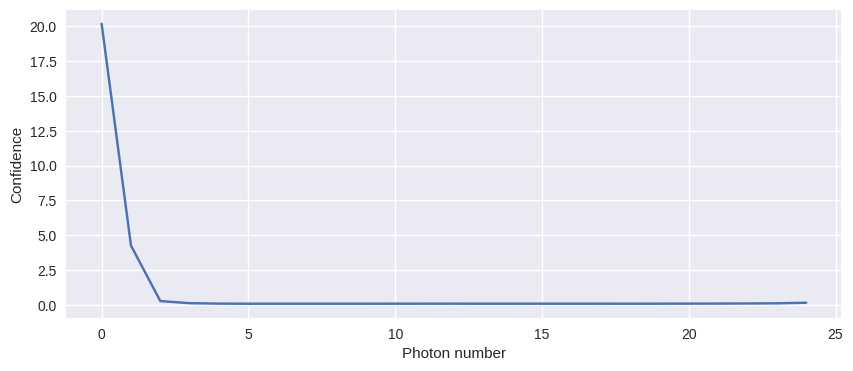

26.5


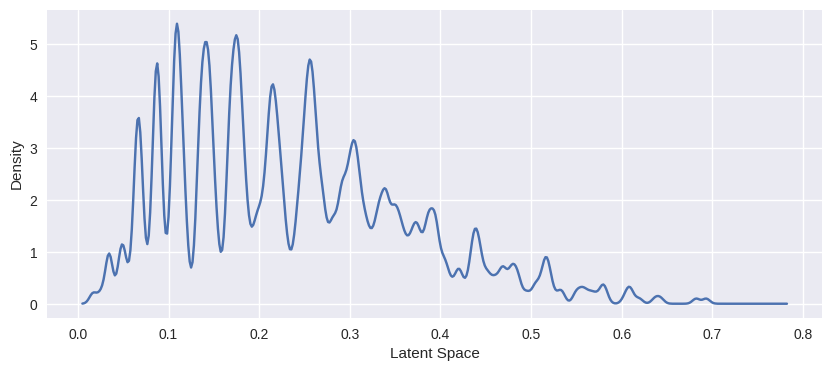

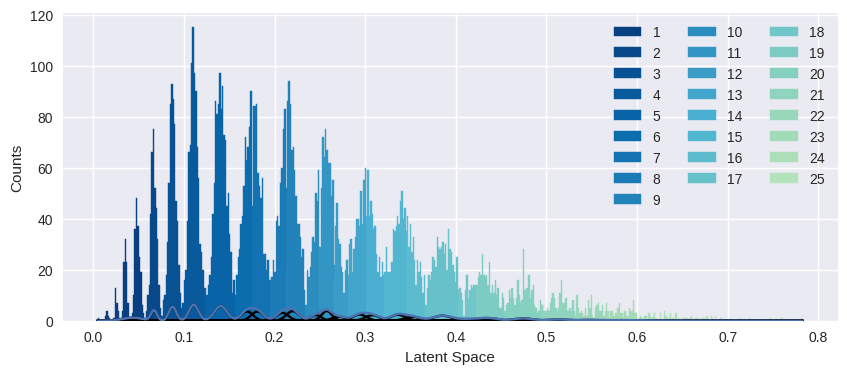

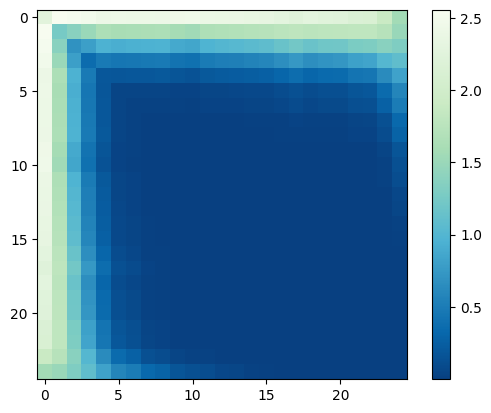

mean 7.35908203125


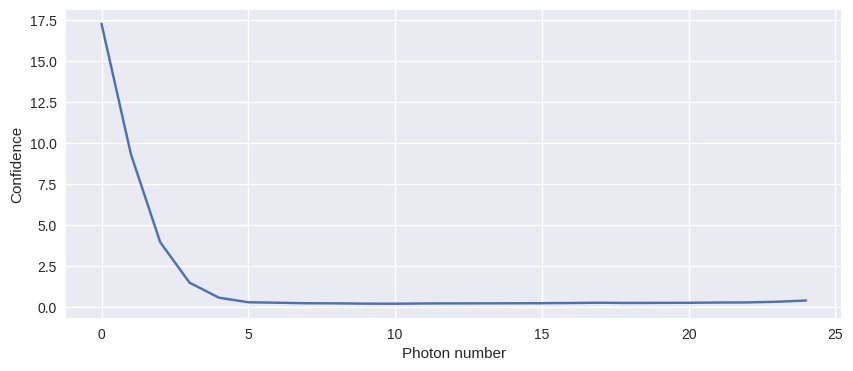

27.0


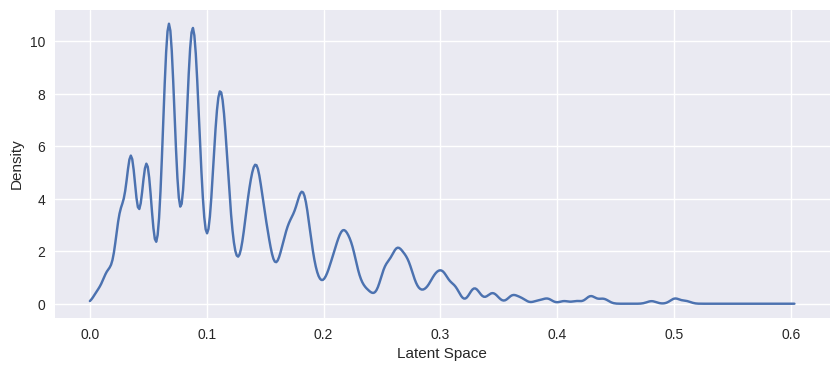

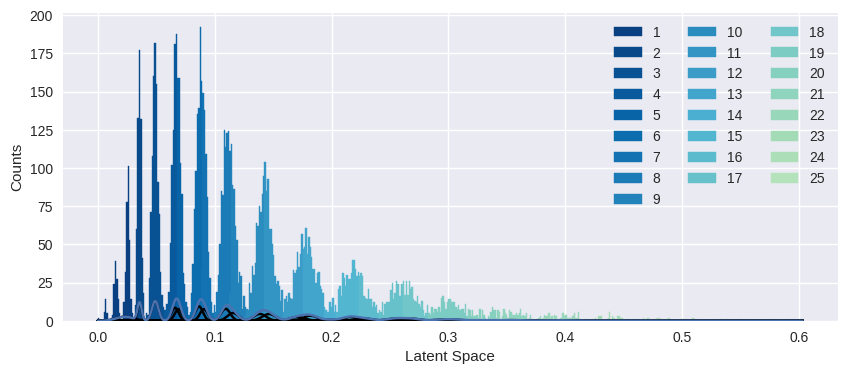

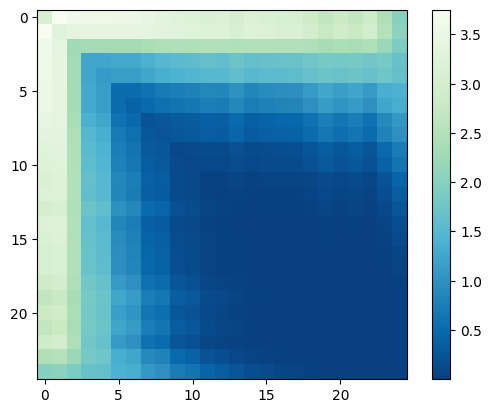

mean 4.4220703125


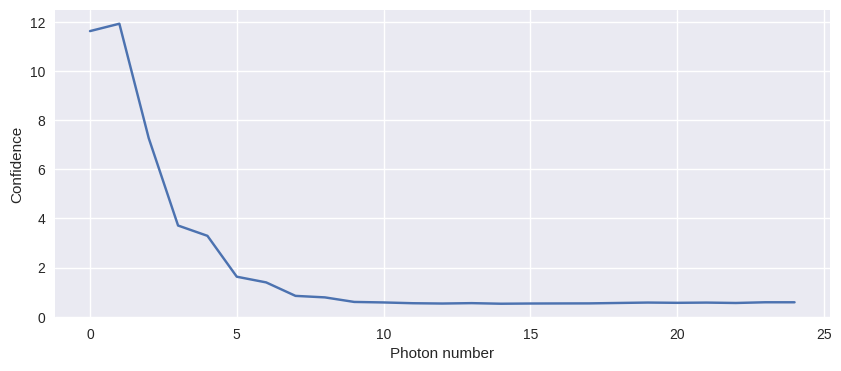

27.5


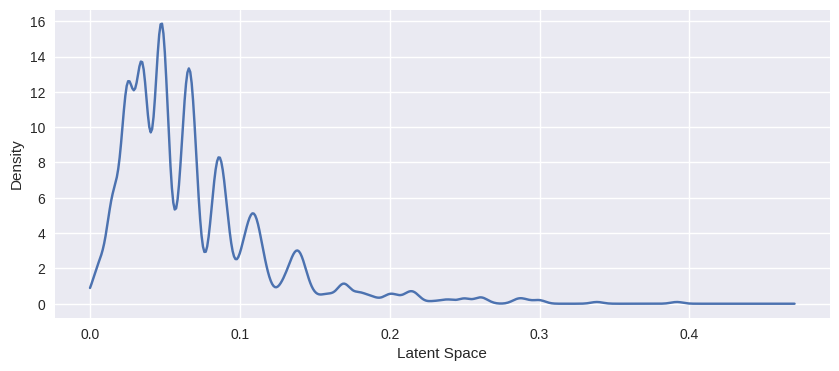

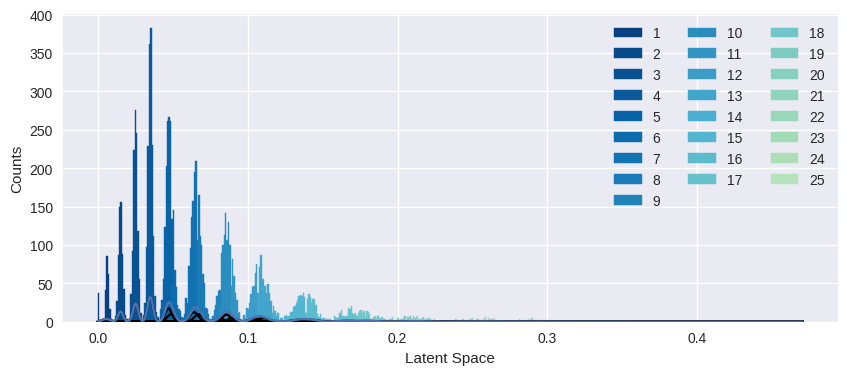

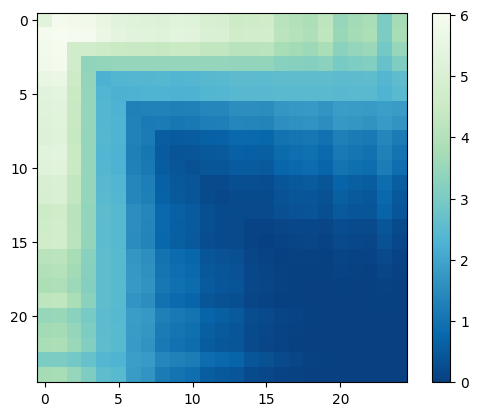

mean 2.7271484375


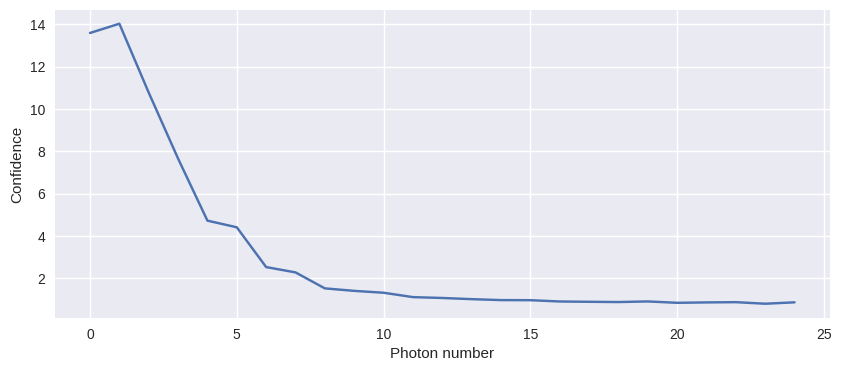

28.0


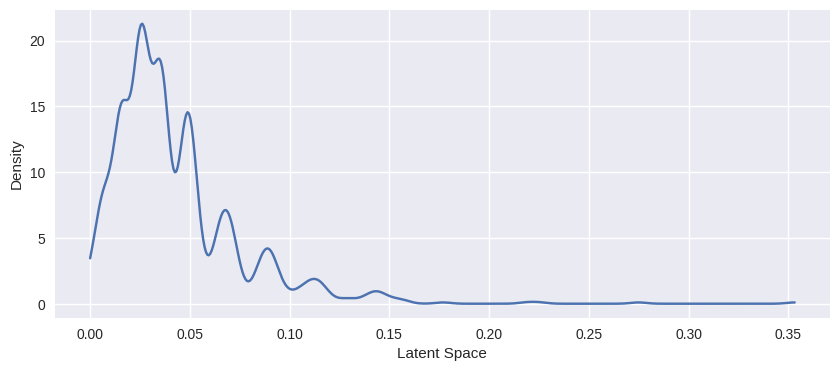

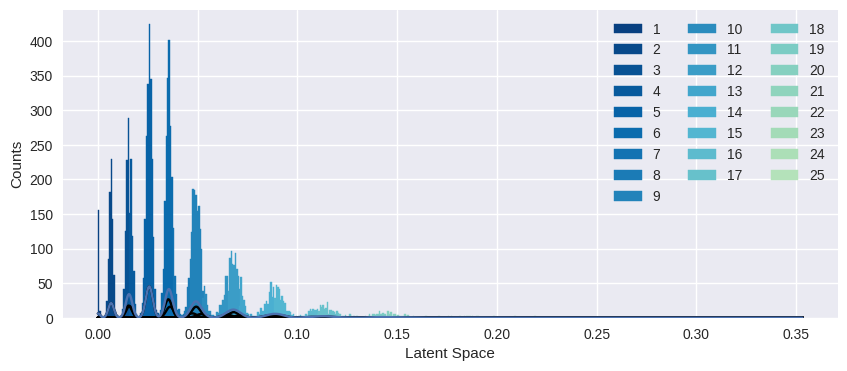

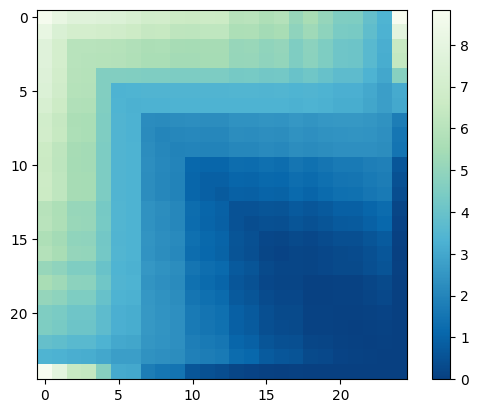

mean 1.78671875


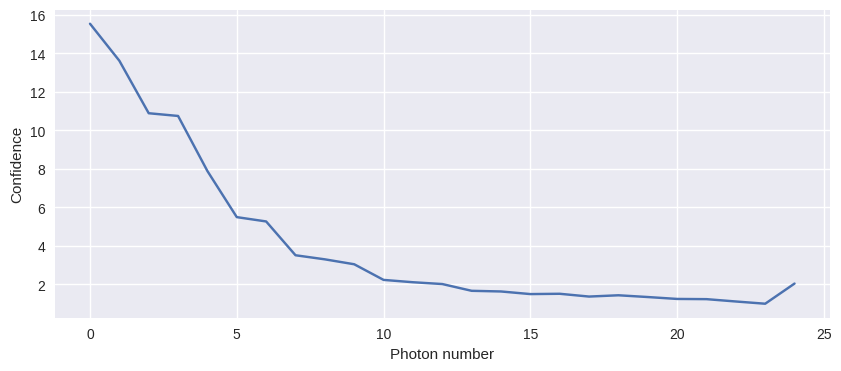

28.5


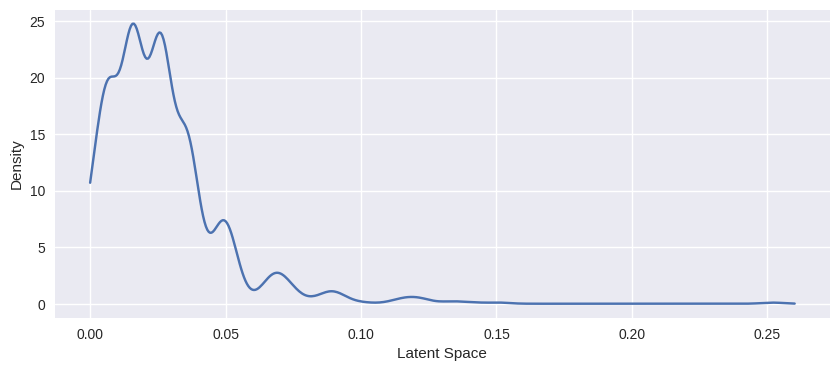

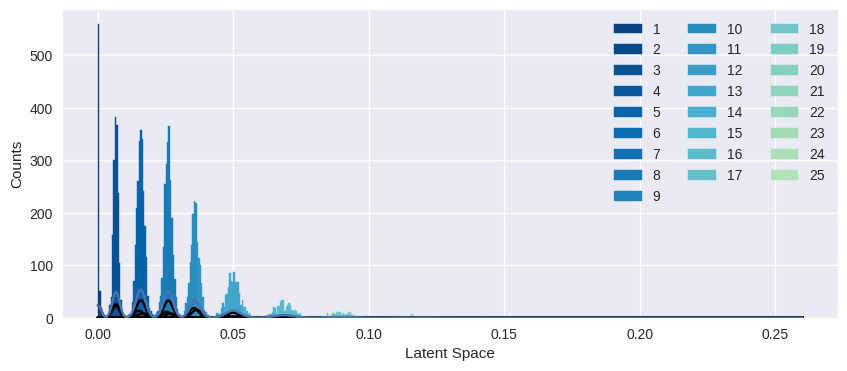

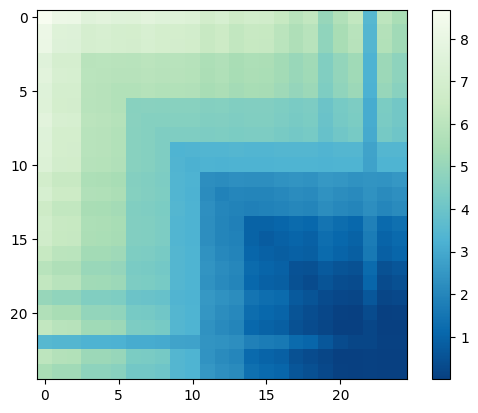

mean 1.17763671875


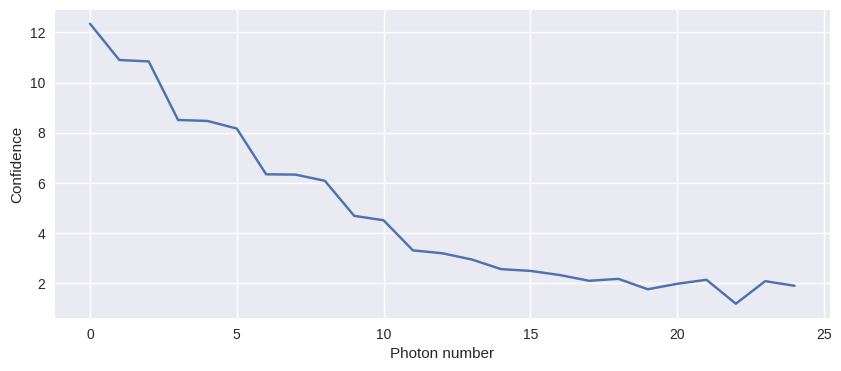

29.0


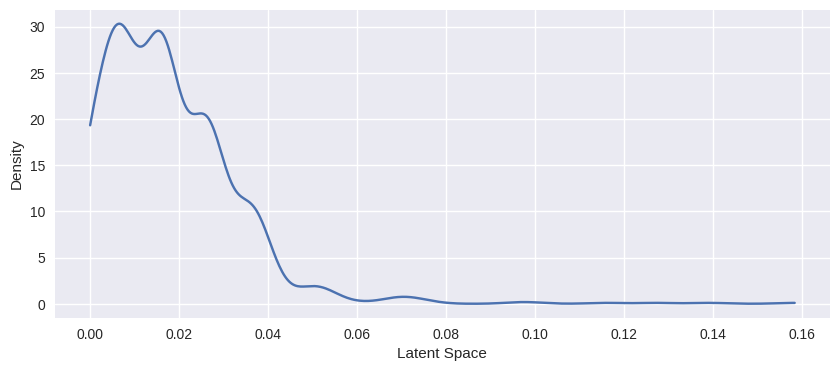

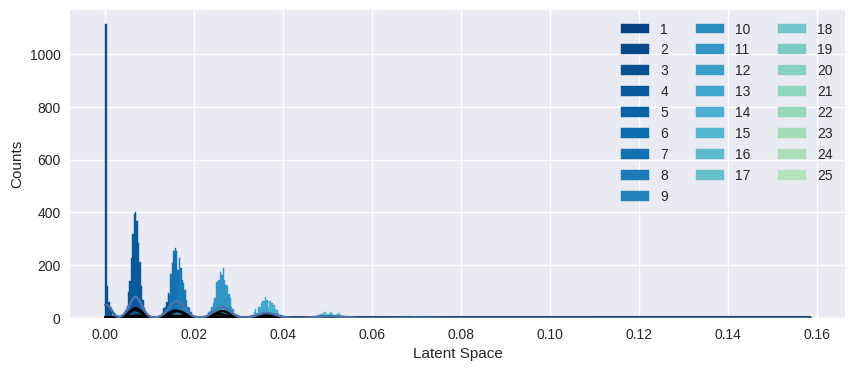

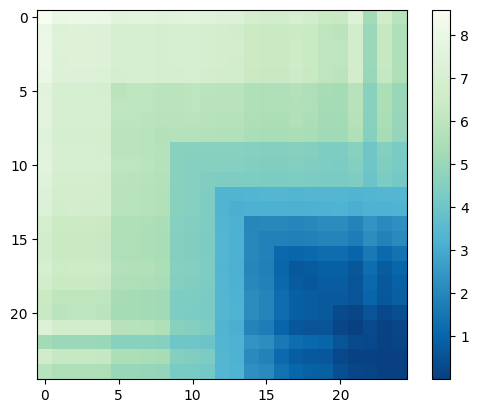

mean 0.75419921875


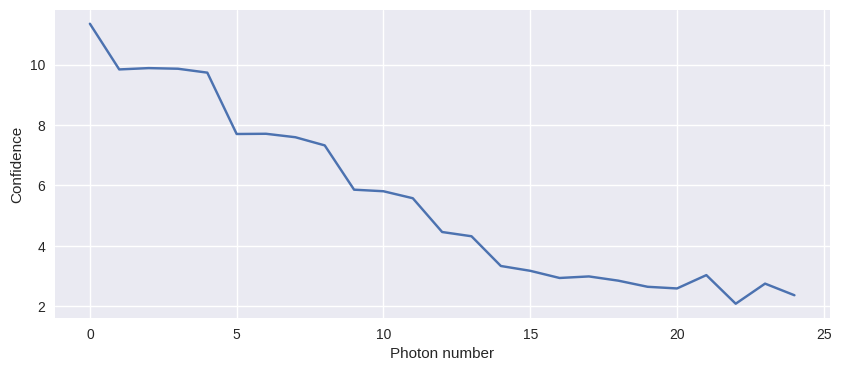

In [10]:
decibel = []
g2 = []
average = []

X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(X, f'AutoencoderLog/{path_model}', filter=False, flip=False)

conf = confidence(X_l_AUTO,
                bw = [0.003], 
                bins_plot = 5000,
                number_cluster=25,
                #min_cluster_prob=0.003,
                density_kernel='gaussian',
                flip = False, 
                skip = 10,
                size_plot = 10)

labels = conf.labels

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key

    conf.fit(X_l_AUTO[condition],
            bw = [0.004], 
            bins_plot = 500,
            number_cluster=25,
            #min_cluster_prob=0.001,
            density_kernel='gaussian',
            flip = False, 
            skip = 10,
            size_plot = 10)
    
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

# dB evaluation

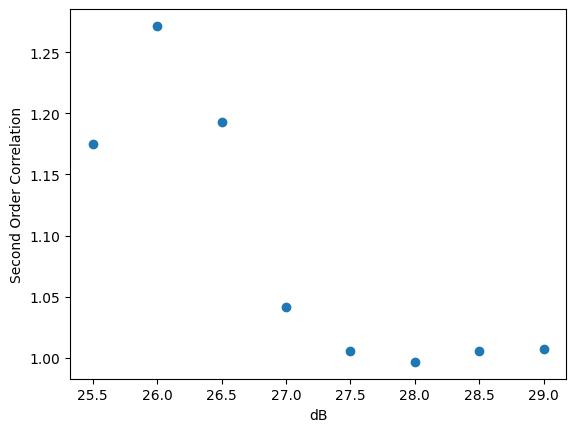

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-cst*dB )

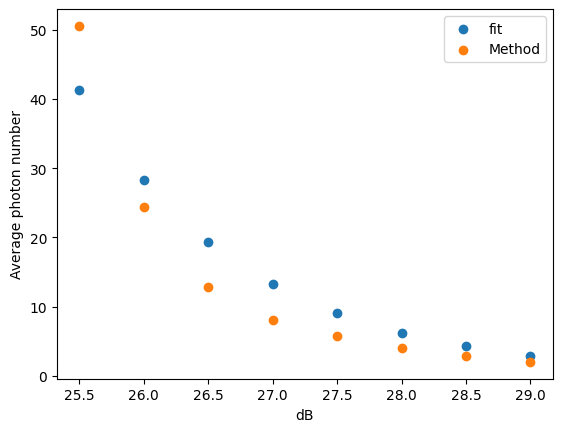

[1.00000000e+10 3.28759638e-01]


In [ ]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -100], [1e10, 100]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt), label='fit')
plt.scatter(decibel, average,marker='o', label='Method')
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.legend()
plt.show()
print(popt)

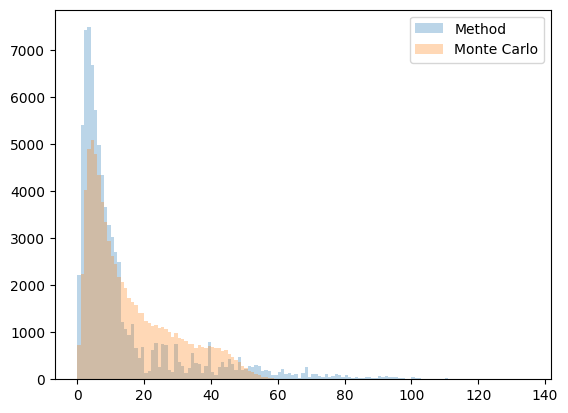

In [ ]:
import numpy.random as npr

average_ = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average_])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poissonian statistic for t-SNE

In [18]:
X, decibel_samples = decibel_table_bin('Datasets/TES/NIST train',
                                8192,
                                (67,71))

X = -1* X[:,0:270]
#X = X[:,::2]

In [ ]:
#method = TSNE(n_components=1, perplexity=1000)
#X_l = method.fit_transform(X)

In [12]:
method = TSNE(n_components=2, perplexity=2000)
X_l = method.fit_transform(X)
#np.save("MetricLog/Metric_TES/temp_tsne_TES1000_2D",X_l)

In [9]:
np.save("MetricLog/Metric_TES/temp_tsne_TES2000_2D",X_l)

In [22]:
#np.save("temp_tsne_TES1000_L",X_l)
X_l = np.load("MetricLog/Metric_TES/temp_tsne_TES2000_2D.npy")

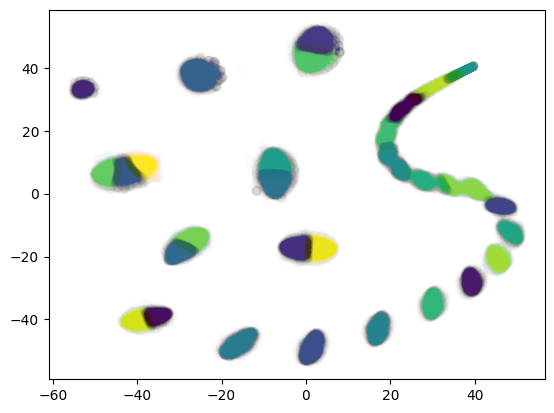

In [25]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=30).fit(X_l)
labels = gmm.predict(X_l)
plt.scatter(X_l[:, 0], X_l[:, 1],alpha=0.005, c=labels, s=40, cmap='viridis');
plt.show()

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:108: RuntimeWarning: invalid value encountered in sqrt
  mins[i] = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


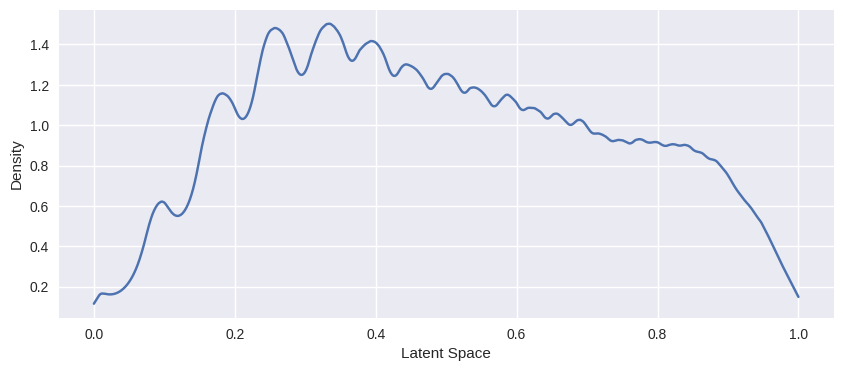

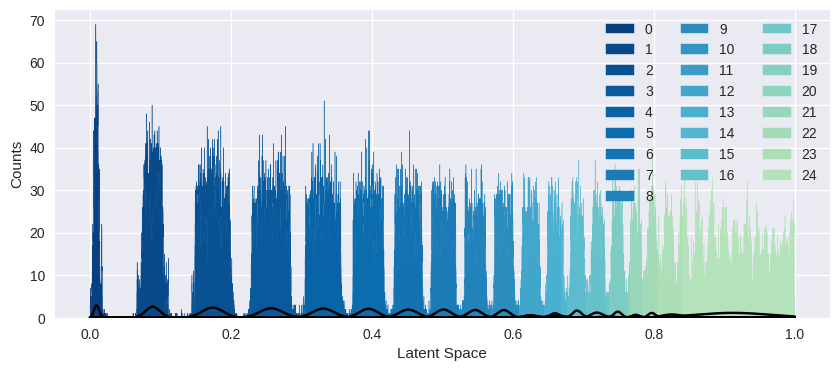

/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: divide by zero encountered in divide
  ret = um.true_divide(
/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


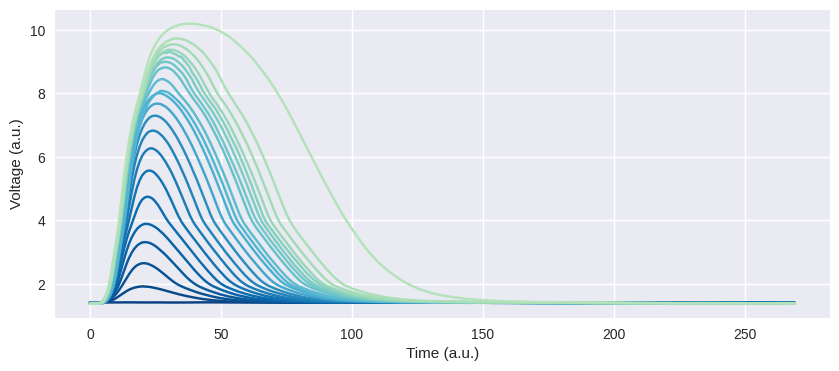

In [ ]:
X_l = (X_l - np.min(X_l)) / (np.max(X_l) - np.min(X_l))

kd = density_gaussianMixture(X_l, 
                            bw = [0.05], #0.012
                            bins_plot = 5000,
                            density_kernel='exponential',
                            flip = False, 
                            skip = 10,
                            size_plot = 10)

kd.plot_density()
kd.plot_cluster()
kd.plot_traces_average(X)
labels = kd.labels

In [ ]:
decibel = []
g2 = []
average = []
bw = []

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

23.5
24.0
24.5
25.0
25.5
26.0
26.5
27.0
27.5
28.0
28.5
29.0


# dB evaluation

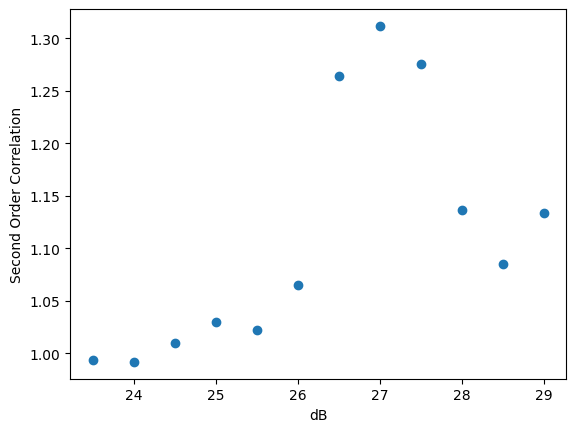

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-cst*dB )

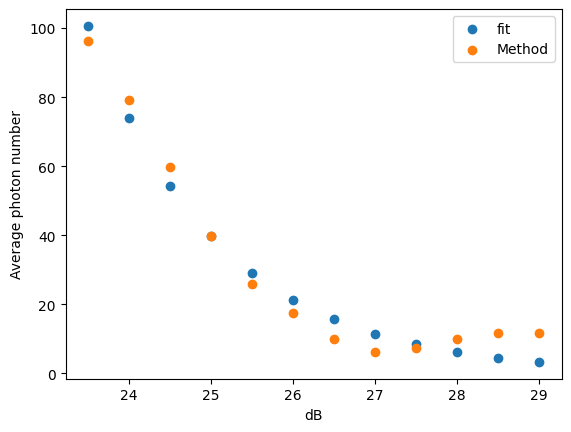

[2.10437081e+08 2.68952385e-01]


In [ ]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -100], [1e9, 100]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt), label='fit')
plt.scatter(decibel, average,marker='o', label='Method')
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.legend()
plt.show()
print(popt)

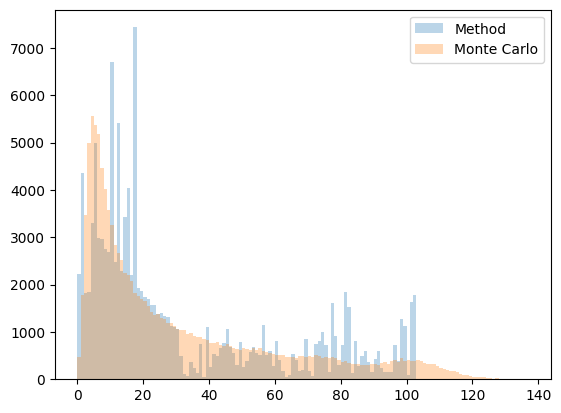

In [ ]:
import numpy.random as npr

average_ = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average_])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poissonian statistics for PCA

In [44]:
X, decibel_samples = decibel_table_bin('Datasets/TES/NIST train',
                                8192,
                                (67,71))

X = -1* X[:,0:250]
X = X[:, ::2]

In [45]:
method = PCA(n_components=1)
X_l = method.fit_transform(X)

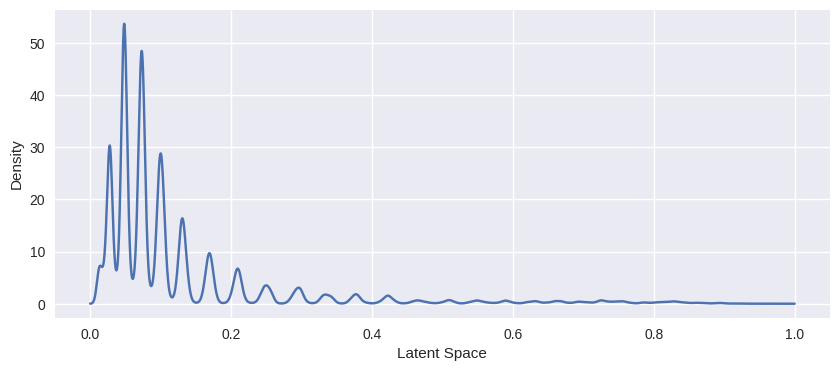

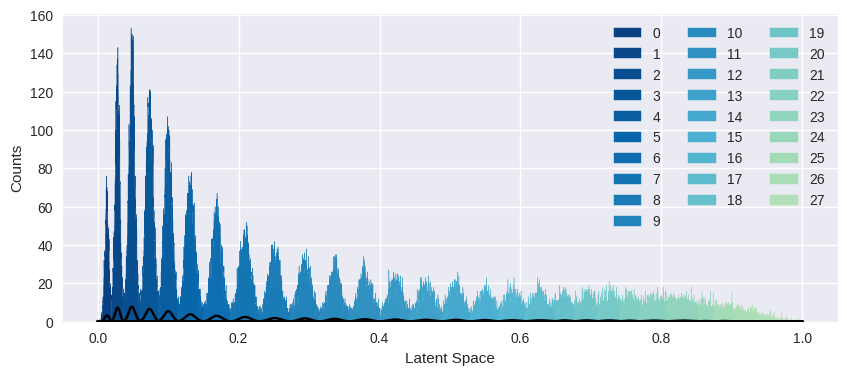

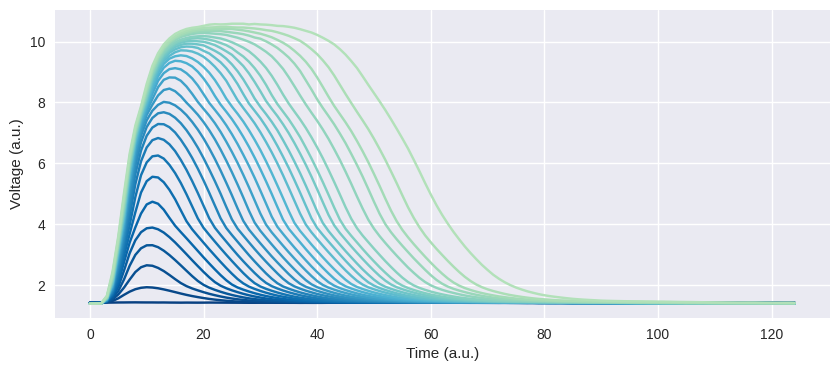

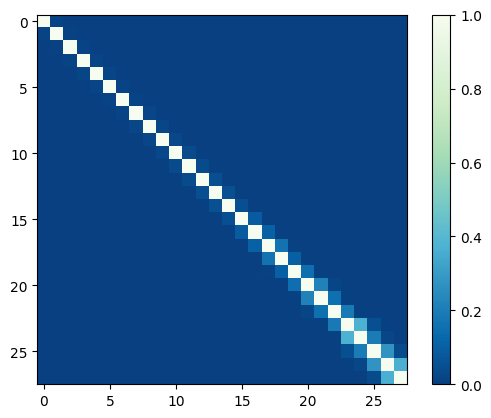

In [46]:
X_l = (X_l - np.min(X_l)) / (np.max(X_l) - np.min(X_l))

kd = density_gaussianMixture(X_l, 
                            bw = [0.0045], 
                            bins_plot = 5000,
                            min_cluster_prob=0.003,
                            flip = False, 
                            skip = 10)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces_average(X)
kd.plot_cross_talk()
labels = kd.labels

In [47]:
decibel = []
g2 = []
average = []
bw = []

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

25.5
26.0
26.5
27.0
27.5
28.0
28.5
29.0


# dB evaluation

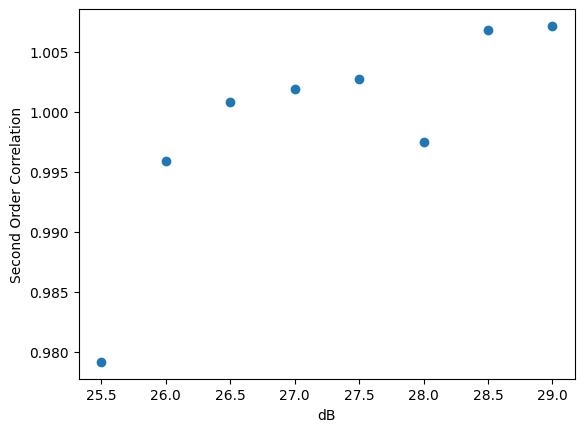

In [48]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [49]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-cst*dB )

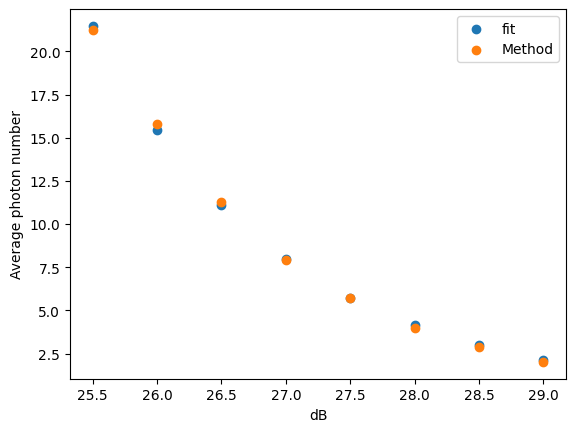

[4.25169748e+08 2.86143561e-01]


In [50]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -100], [1e9, 100]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt), label='fit')
plt.scatter(decibel, average,marker='o', label='Method')
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.legend()
plt.show()
print(popt)

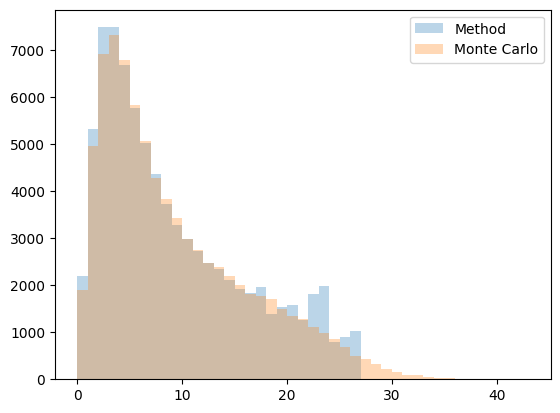

In [51]:
import numpy.random as npr

average_ = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average_])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()